# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student:** Kathryn Choi

**Date:** 9/4/2026

In [1]:
# Importing Google Drive to upload data files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Your Phase 1 solution to the problem goes here.

In [2]:
# Q1.1 - Cleaning the 'Price' variable
import pandas as pd
import numpy as np

# Reading csv file
df = pd.read_csv('/content/drive/MyDrive/Fall 2026/DS 3001 - Intro to Machine Learning/A01 - Data Wrangling/airbnb_hw.csv')

# Looking at potential issues before cleaning
print(f"Sorted Values Before Cleaning: {sorted(df['Price'].unique())}")

# Checking for any missing values (no missing values found)
print(f"Number of Missing Values Before Cleaning: {df['Price'].isna().sum()}")

# Removing all dollar signs and commas
df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

# Converting 'Price' to a numeric data type
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Checking to make sure that the values are correctly ordered after cleaning
print(f"Sorted Values After Cleaning: {sorted(df['Price'].unique())}")

# Count number of missing values after cleaning
print(f"Number of Missing Values After Cleaning: {df['Price'].isna().sum()}")


# I removed the dollar signs and commas so that I could standardize all of the 'Price' values. For example, when the price goes over 999,
# some values may have a comma, like in 1,234. Furthermore, by removing the commas I could properly sort the 'Price' variable and see
# all of the 'Price' values listed from least to greater in the correct order. After removing all '$' and ',' I converted 'Price' to
# a numeric data type so that relevant functions like .mean() could be use and insights about the 'Price' variable could be gathered.
# There are no missing values in the 'Price' variable before or after cleaning.


Sorted Values Before Cleaning: ['1,000', '1,050', '1,065', '1,100', '1,111', '1,170', '1,174', '1,195', '1,200', '1,239', '1,250', '1,300', '1,350', '1,356', '1,368', '1,400', '1,495', '1,499', '1,500', '1,550', '1,600', '1,650', '1,700', '1,750', '1,800', '1,850', '1,900', '1,990', '1,999', '10', '10,000', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198'

In [3]:
# Q1.2 - Cleaning the 'subject_injury' variable
import pandas as pd
import numpy as np

# Reading csv file
df = pd.read_csv('/content/drive/MyDrive/Fall 2026/DS 3001 - Intro to Machine Learning/A01 - Data Wrangling/mn_police_use_of_force.csv')


# Finding proportion of missing 'subject_injury' values
percent_missing = (df['subject_injury'].isna().sum()) / (len(df['subject_injury'])) * 100
print(f"Proportion Missing: {percent_missing:.2f}%")

# 76.19% of 'subject_injury' values are missing, which is a concern since a large majority of the data for that variable is not available.

# Replacing missing 'subject_injury' values with 'Unknown'
df['subject_injury'] = df['subject_injury'].fillna('Unknown')

# Cross-tabulating the cleaned 'subject_injury' variable with 'force_type' variable
display(pd.crosstab(df['subject_injury'], df['force_type']))


# Based on the cross-tabulation table, the primary force types for which the 'subject_injury' variable is missing are Baton, Bodily Force,
# Chemical Irritant, Improvised Weapon, Less Lethal, Maximal Restraint Technique, and Taser. I identified these force types based on if
# the total number of 'Unknown' cases was greater than or equal to the total number of 'No' or 'Yes' cases. The force types 'Less Lethal' and
# 'Maximal Restraint Technique' do not have any recorded 'Yes' or 'No' cases for the 'subject_injury' variable which shows that those force
# types never have subject injuries recorded. High-frequency force types such as 'Bodily Force,' 'Chemical Irritant,' and 'Taser' are also
# more likely to have unknown subject injuries recorded.

Proportion Missing: 76.19%


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Unknown,2,7051,1421,0,27,74,87,0,170,31,985
Yes,2,1286,41,0,44,40,0,2,0,44,172


In [4]:
# Q2.1 & Q2.2 - Opening shark attack file and dropping empty columns
import pandas as pd
import numpy as np

# Opening shark attack file
df = pd.read_excel('/content/drive/MyDrive/Fall 2026/DS 3001 - Intro to Machine Learning/A01 - Data Wrangling/GSAF5.xls')

# Printing all of the column names BEFORE dropping the empty ones
print(f"Columns Before Cleaning: {df.columns.tolist()}")

# Coverting all "empty" columns (empty strings or strings with only whitespace) to NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Dropping all null columns
df = df.dropna(axis=1, how='all')

# Dropping unnamed columns
df = df.drop(columns=df.loc[:,df.columns.str.contains('^Unnamed')])

# Printing all of the column names AFTER dropping the empty ones
print(f"Columns After Cleaning: {df.columns.tolist()}")

Columns Before Cleaning: ['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22']
Columns After Cleaning: ['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order']


Oldest Year Before Cleaning: 1940
Newest Year Before Cleaning: 2026
Oldest Year After Cleaning: 1940
Newest Year After Cleaning: 2026


Text(0, 0.5, 'Number of Attacks')

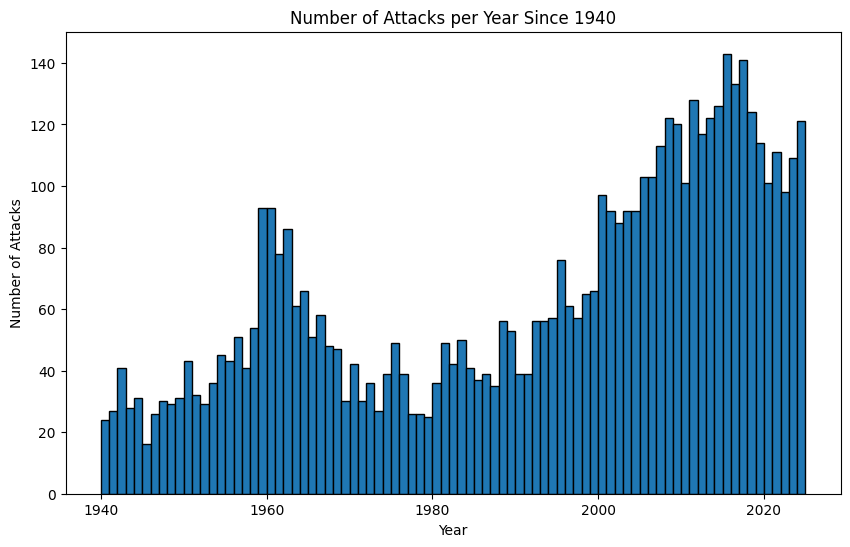

In [7]:
# Q2.3 - Cleaning the 'year' variable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Converting 'Year' to a integer data type
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Year'] = df['Year'].astype(int)  # See note below

# Note: for some reason, the line above throws an error the first time it runs, but if you delete the line, rerun the code block (which will
# still throw an error), and then undo delete the line above, the code block will work.


# Printing the range of 'Year' values
print(f"Oldest Year Before Cleaning: {df['Year'].min():.0f}")
print(f"Newest Year Before Cleaning: {df['Year'].max():.0f}")

# Before cleaning, the years range from 0 to 2026


# Filtering to focus on attacks since 1940
df = df[df['Year'] >= 1940]

# Printing the range of 'Year' values
print(f"Oldest Year After Cleaning: {df['Year'].min():.0f}")
print(f"Newest Year After Cleaning: {df['Year'].max():.0f}")

# Graphing the pattern of attacks since 1940
plt.figure(figsize=(10,6))
plt.title("Number of Attacks per Year Since 1940")
plt.hist(df['Year'], bins=range(df['Year'].min(), df['Year'].max()), edgecolor='black')
plt.xlabel("Year")
plt.ylabel("Number of Attacks")


# Based on the graph, the number of attacks is increasing over time.

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s' '23 & 20' 5
 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30' '16 to 18' '

<Axes: >

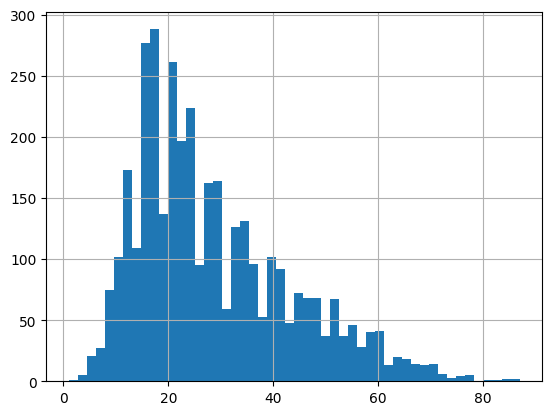

In [8]:
# Q2.4 - Cleaning the 'age' variable
import pandas as pd
import numpy as np

# Printing all of the different age values before cleaning
print(df['Age'].unique())

# Converting 'Age' to a integer data type, setting all errors (not strictly numeric values) to NaN
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Creating a histogram of victim ages
df['Age'].hist(bins=50)

In [9]:
# Q2.5 - Proportion of male victims
import pandas as pd
import numpy as np

# Printing all of the different sex values before cleaning
print(f"Unique Sex Values Before Cleaning: {df['Sex'].unique()}")

# Getting rid of whitespaces first and standardizing casing
df['Sex_Cleaned'] = df['Sex'].astype(str).str.lower().str.strip()

# A function to sort data values as sex categories
def sort_sex(sex_value):
  if 'm' in sex_value:
    return 'M'
  elif 'f' in sex_value:
    return 'F'
  else:
    return 'Unknown'

df['Sex_Cleaned'] = df['Sex_Cleaned'].apply(sort_sex)

# Printing all of the different sex values after cleaning
print(f"Unique Sex Values After Cleaning: {df['Sex_Cleaned'].unique()}")

# Finding the proportion of men
prop_male = (df[df['Sex_Cleaned'] == 'M'].shape[0]) / (df.shape[0]) * 100
print(f"Proportion of Male Victims: {prop_male:.2f}%")

Unique Sex Values Before Cleaning: ['F' 'M' 'M ' 'M F' '?' 'F ' nan ' M' 'm' 'lli' 'M x 2']
Unique Sex Values After Cleaning: ['F' 'M' 'Unknown']
Proportion of Male Victims: 78.75%


In [10]:
# Q2.6 - Cleaning the 'Type' variable
import pandas as pd
import numpy as np

# Printing all of the different type values before cleaning
print(f"Unique Type Values Before Cleaning: {df['Type'].unique()}")

# Removing all whitespaces and standardizing casing
df['Type_Cleaned'] = df['Type'].astype(str).str.lower().str.strip()

# A function to sort data values into type categories
def sort_type(type_value):
  if 'unprovoked' in type_value:
    return 'Unprovoked'
  elif 'provoked' in type_value:
    return 'Provoked'
  else:
    return 'Unknown'

df['Type_Cleaned'] = df['Type_Cleaned'].apply(sort_type)

# Printing all of the different type values after cleaning
print(f"Unique Type Values After Cleaning: {df['Type_Cleaned'].unique()}")

# Finding the proportion of unprovoked attacks
prop_unp = (df[df['Type_Cleaned'] == 'Unprovoked'].shape[0]) / (df.shape[0]) * 100
print(f"Proportion of Unprovoked Attacks: {prop_unp:.2f}%")

Unique Type Values Before Cleaning: ['Unprovoked' 'Provoked' 'Questionable' 'UNprovoked' 'unprovoked'
 ' Provoked' 'Watercraft' 'Sea Disaster' nan '?' 'Unconfirmed'
 'Unverified' 'Invalid' 'Under investigation' 'Boat']
Unique Type Values After Cleaning: ['Unprovoked' 'Provoked' 'Unknown']
Proportion of Unprovoked Attacks: 74.59%


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 8d6502c
- **AI tool and model used:** Google Colab Gemini 3 Flash

### *Prompts used

1. Please read over the two questions and their sub-questions posed at the top of the notebook regarding the airbnb_hw.csv and mn_police_use_of_force.csv files (Question 1) and the shark attack file (Question 2). Then look over the rest of my notebook for my answers to all of the questions. Provide comments detailing changes you would make to my answers in order to improve them considering the following rubric:
1a. Airbnb Price — Attempt to clean
1b. Airbnb Price — Quality of cleaning 1c. Airbnb Price — Explanation
2a. subject_injury — Attempt to clean
2b. subject_injury — Correct Yes/No values
2c. subject_injury — Explanation of missingness
2d. Cross-tabulation — Attempt
2e. Cross-tabulation — Correctness
2f. Cross-tabulation — Interpretation
2.1 Load dataset & remove empty columns
2.2 Clean Year — Attempt
2.3 Clean Year — Quality
2.4 Year — Explanation/trend
2.5 Clean Age & create histogram — Attempt
2.6 Age — Quality of cleaning
2.7 Age — Histogram
2.8 Proportion of male victims
2.9 Clean Type — Attempt
2.10 Clean Type — Quality
2.11 Proportion unprovoked
2. For your suggestion for Q1.2, is it appropriate to fill in missing values with predictions rather than just "Unknown" since there is no injury_description variable?
3. Additionally, for your suggestion for Q2.4, is it not discouraged to make assumptions for victim age? Although some non-numeric data types include some helpful information, we cannot interpret someone's age based on information like "20s" or "teen" or "mid-30s" so shouldn't those data be changed to Unknown?
4. I think that splitting the bins into age categories would cause problems since some of the non-numeric data values have a range of values that be difficult to separate into uniform bins. However, I saw that there were some data entries that included data for two victims in one entry so the ages are split by "and" or "&" and are thus not registered. Would it be beneficial to write a function to split up those types of values since they do include valid ages?

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Q1.1: Airbnb Price Cleaning
Improvement: While your manual removal of symbols works, using a regular expression like [^0-9.] is safer. Your code currently converts to float (numeric) but doesn't explicitly check for values that might be zero or extremely low, which could be outliers.
2. Q1.2: Police Use of Force
Improvement: Instead of filling all NA with 'Unknown', check if force_type or injury_description provides clues. For the proportion question, explicitly state the decimal or percentage in your explanation text, not just the code output.
3. Q2.3 (Year): You mentioned a bug with astype(int). This usually happens because pd.to_numeric produces floats if there are NaNs. Use df['Year'].astype('Int64') (capital I) to allow integers with NaNs without crashing.
4. Q2.4 (Age): Your current to_numeric(errors='coerce') deletes useful data like "20s", "teen", and "mid-30s". You should use string splitting or regex to extract the first number from strings like "28 & 22" before converting.
5. Q2.6 (Type): Your sort_type function is good, but check for "Invalid" or "Sea Disaster" specifically—your current logic maps "Sea Disaster" to "Unknown", which is acceptable but could be more precise.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | I did not account for potential outliers in terms of numbers that are unreasonably small or even zero so this suggestion is valid and aids in the data cleaning process. This was verified by counting all of the data points that were less than or equal to zero. |
| 2 | Reject | For the missing subject_injury entries, is it not valid to make assumptions based on other variable entries (which the AI would not know about since it does not have access to the file data). Furthermore, since a large majority of the subject_injury values were missing, we would not be able to reasonable determine a pattern based on the available data. |
| 3 | Accept | There was a slight bug in my conversion to an integer data type, so this fix can help address the bug. This was verified by running the code and seeing that it provided the correct response without having to be run multiple times like in my earlier attempt. |
| 4 | Modify | While inferring ages from non-numeric age values like "teen" or "mid-30s" can be problematic, data entries that include information for two victim can be reasonably split up for more accurate age representation and an accurate count of victims. This was verified by printing the unique age values after cleaning and ensuring that there were only valid integer values left.|
| 5 | Reject | The question states that there should only be three 'Type' responses: Provoked, Unprovoked, and Unknown. Responses outside of the three mentioned should be mapped to one of them rather than making separate categories. This was validated by printing the type values after cleaning and ensuring that only the aforemention three were left. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [33]:
# Q1.1 - Cleaning the 'Price' variable
import pandas as pd
import numpy as np

# Reading csv file
df_airbnb = pd.read_csv('/content/drive/MyDrive/Fall 2026/DS 3001 - Intro to Machine Learning/A01 - Data Wrangling/airbnb_hw.csv')

# Looking at potential issues before cleaning
print(f"Sorted Values Before Cleaning: {sorted(df_airbnb['Price'].unique())}")

# Checking for any missing values (no missing values found)
print(f"Number of Missing Values Before Cleaning: {df_airbnb['Price'].isna().sum()}")

# Removing anything that isn't a digit or decimal point
df_airbnb['Price'] = df_airbnb['Price'].astype(str).str.replace(r'[^0-9.]', '', regex=True)

# Converting 'Price' to a numeric data type
df_airbnb['Price'] = pd.to_numeric(df_airbnb['Price'], errors='coerce')

# Check for outliers (e.g., prices that are $0 or abnormally low)
low_price_outliers = df_airbnb[df_airbnb['Price'] <= 0]
print(f"Potential Outliers: {df_airbnb['Price'].isna().sum()}")

# Checking to make sure that the values are correctly ordered after cleaning
print(f"Sorted Values After Cleaning: {sorted(df_airbnb['Price'].unique())}")

# Count number of missing values after cleaning
print(f"Number of Missing Values After Cleaning: {df_airbnb['Price'].isna().sum()}")


# I removed everything that wasn't a digit or decimal point so that I could standardize all of the 'Price' values. For example, when the price goes over 999,
# some values may have a comma, like in 1,234. Furthermore, by removing the commas I could properly sort the 'Price' variable and see
# all of the 'Price' values listed from least to greater in the correct order. After removing any unnecessary components, I converted 'Price' to
# a numeric data type so that relevant functions like .mean() could be use and insights about the 'Price' variable could be gathered. I also check for any outliers
# (i.e. numbers less than or equal to zero).
# There are no missing values in the 'Price' variable before or after cleaning.


Sorted Values Before Cleaning: ['1,000', '1,050', '1,065', '1,100', '1,111', '1,170', '1,174', '1,195', '1,200', '1,239', '1,250', '1,300', '1,350', '1,356', '1,368', '1,400', '1,495', '1,499', '1,500', '1,550', '1,600', '1,650', '1,700', '1,750', '1,800', '1,850', '1,900', '1,990', '1,999', '10', '10,000', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198'

In [34]:
# Q1.2 - Cleaning the 'subject_injury' variable
import pandas as pd
import numpy as np

# Reading csv file
df_police = pd.read_csv('/content/drive/MyDrive/Fall 2026/DS 3001 - Intro to Machine Learning/A01 - Data Wrangling/mn_police_use_of_force.csv')


# Finding proportion of missing 'subject_injury' values
percent_missing = (df_police['subject_injury'].isna().sum()) / (len(df_police['subject_injury'])) * 100
print(f"Proportion Missing: {percent_missing:.2f}%")

# 76.19% of 'subject_injury' values are missing, which is a concern since a large majority of the data for that variable is not available.

# Replacing missing 'subject_injury' values with 'Unknown'
df_police['subject_injury'] = df_police['subject_injury'].fillna('Unknown')

# Cross-tabulating the cleaned 'subject_injury' variable with 'force_type' variable
display(pd.crosstab(df_police['subject_injury'], df_police['force_type']))


# Based on the cross-tabulation table, the primary force types for which the 'subject_injury' variable is missing are Baton, Bodily Force,
# Chemical Irritant, Improvised Weapon, Less Lethal, Maximal Restraint Technique, and Taser. I identified these force types based on if
# the total number of 'Unknown' cases was greater than or equal to the total number of 'No' or 'Yes' cases. The force types 'Less Lethal' and
# 'Maximal Restraint Technique' do not have any recorded 'Yes' or 'No' cases for the 'subject_injury' variable which shows that those force
# types never have subject injuries recorded. High-frequency force types such as 'Bodily Force,' 'Chemical Irritant,' and 'Taser' are also
# more likely to have unknown subject injuries recorded.

Proportion Missing: 76.19%


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Unknown,2,7051,1421,0,27,74,87,0,170,31,985
Yes,2,1286,41,0,44,40,0,2,0,44,172


In [35]:
# Q2.1 & Q2.2 - Opening shark attack file and dropping empty columns
import pandas as pd
import numpy as np

# Opening shark attack file
df_shark = pd.read_excel('/content/drive/MyDrive/Fall 2026/DS 3001 - Intro to Machine Learning/A01 - Data Wrangling/GSAF5.xls')

# Printing all of the column names BEFORE dropping the empty ones
print(f"Columns Before Cleaning: {df_shark.columns.tolist()}")

# Coverting all "empty" columns (empty strings or strings with only whitespace) to NaN
df_shark = df_shark.replace(r'^\s*$', np.nan, regex=True)

# Dropping all null columns
df_shark = df_shark.dropna(axis=1, how='all')

# Dropping unnamed columns
df_shark = df_shark.drop(columns=df_shark.loc[:,df_shark.columns.str.contains('^Unnamed')])

# Printing all of the column names AFTER dropping the empty ones
print(f"Columns After Cleaning: {df_shark.columns.tolist()}")

Columns Before Cleaning: ['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22']
Columns After Cleaning: ['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order']


Oldest Year Before Cleaning: 0
Newest Year Before Cleaning: 2026
Oldest Year After Cleaning: 1940
Newest Year After Cleaning: 2026


Text(0, 0.5, 'Number of Attacks')

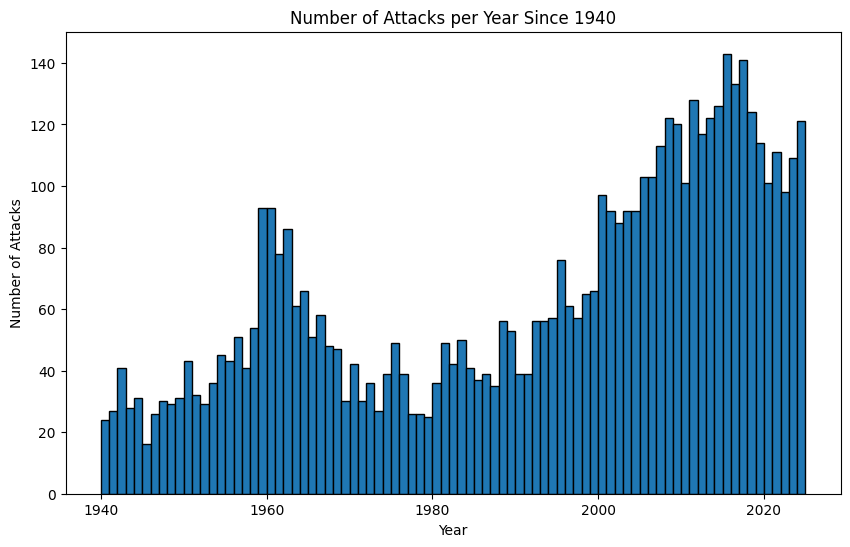

In [36]:
# Q2.3 - Cleaning the 'year' variable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Converting 'Year' to a integer data type
df_shark['Year'] = pd.to_numeric(df_shark['Year'], errors='coerce').astype('Int64')

# Note: for some reason, the line above throws an error the first time it runs, but if you delete the line, rerun the code block (which will
# still throw an error), and then undo delete the line above, the code block will work.


# Printing the range of 'Year' values
print(f"Oldest Year Before Cleaning: {df_shark['Year'].min():.0f}")
print(f"Newest Year Before Cleaning: {df_shark['Year'].max():.0f}")

# Before cleaning, the years range from 0 to 2026


# Filtering to focus on attacks since 1940
df_shark_clean = df_shark[df_shark['Year'] >= 1940]

# Printing the range of 'Year' values
print(f"Oldest Year After Cleaning: {df_shark_clean['Year'].min():.0f}")
print(f"Newest Year After Cleaning: {df_shark_clean['Year'].max():.0f}")

# Graphing the pattern of attacks since 1940
plt.figure(figsize=(10,6))
plt.title("Number of Attacks per Year Since 1940")
plt.hist(df_shark_clean['Year'], bins=range(df_shark_clean['Year'].min(), df_shark_clean['Year'].max()), edgecolor='black')
plt.xlabel("Year")
plt.ylabel("Number of Attacks")


# Based on the graph, the number of attacks is increasing over time.

Unique Age Values Before Cleaning: [nan 43. 27. 71. 21. 69. 31. 13. 12. 17. 35. 20. 19. 11. 38. 39. 16. 22.
 30. 50. 55. 26. 56. 24. 25. 61. 40. 14. 54. 48. 57.  8. 63.  9.  7. 85.
 18. 66. 37. 42. 45. 60. 29. 58. 36. 23. 28. 68. 33. 15. 41. 49. 46. 65.
 64. 32. 10. 62. 52. 44. 47. 59. 34. 77.  2. 73. 67.  6. 53. 51. 75. 70.
  4. 74.  3. 82. 72.  5. 86. 84. 87.  1. 81. 78.]
Unique Age Values After Cleaning: [nan 43. 27. 71. 21. 69. 31. 13. 12. 17. 35. 20. 19. 11. 38. 39. 16. 22.
 30. 50. 55. 26. 56. 24. 25. 61. 40. 14. 54. 48. 57.  8. 63.  9.  7. 85.
 18. 66. 37. 42. 45. 60. 29. 58. 36. 23. 28. 68. 33. 15. 41. 49. 46. 65.
 64. 32. 10. 62. 52. 44. 47. 59. 34. 77.  2. 73. 67.  6. 53. 51. 75. 70.
  4. 74.  3. 82. 72.  5. 86. 84. 87.  1. 81. 78.]


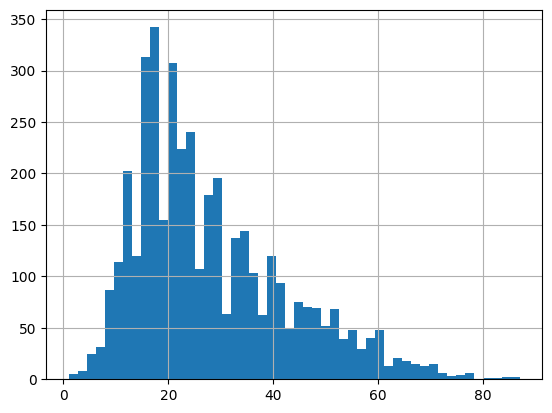

In [42]:
import pandas as pd
import numpy as np
import re

# Show unique values before cleaning
print(f"Unique Age Values Before Cleaning: {df_shark['Age'].unique()}")

# Split multi-victim rows and handle noise like 'Both' or '?'
df_shark['Age'] = df_shark['Age'].astype(str).str.replace(r'\s*(and|&|,|to|Both|both)\s*', '|', regex=True)
df_shark = df_shark.assign(Age=df_shark['Age'].str.split('|')).explode('Age')

# Strip any remaining non-numeric characters (like '?' or spaces) from the individual strings
def extract_number(age_str):
    if pd.isna(age_str): return np.nan
    match = re.search(r'(\d+)', str(age_str))
    return match.group(1) if match else np.nan

df_shark['Age'] = df_shark['Age'].apply(extract_number)

# Converting to a numeric data type
df_shark['Age'] = pd.to_numeric(df_shark['Age'], errors='coerce')

# Show histogram
df_shark['Age'].hist(bins=50)

# Show unique values after cleaning
print(f"Unique Age Values After Cleaning: {df_shark['Age'].unique()}")

In [39]:
# Q2.5 - Proportion of male victims
import pandas as pd
import numpy as np

# Printing all of the different sex values before cleaning
print(f"Unique Sex Values Before Cleaning: {df['Sex'].unique()}")

# Getting rid of whitespaces first and standardizing casing
df['Sex_Cleaned'] = df['Sex'].astype(str).str.lower().str.strip()

# A function to sort data values as sex categories
def sort_sex(sex_value):
  if 'm' in sex_value:
    return 'M'
  elif 'f' in sex_value:
    return 'F'
  else:
    return 'Unknown'

df['Sex_Cleaned'] = df['Sex_Cleaned'].apply(sort_sex)

# Printing all of the different sex values after cleaning
print(f"Unique Sex Values After Cleaning: {df['Sex_Cleaned'].unique()}")

# Finding the proportion of men
prop_male = (df[df['Sex_Cleaned'] == 'M'].shape[0]) / (df.shape[0]) * 100
print(f"Proportion of Male Victims: {prop_male:.2f}%")

Unique Sex Values Before Cleaning: ['F' 'M' 'M ' 'M F' '?' 'F ' nan ' M' 'm' 'lli' 'M x 2']
Unique Sex Values After Cleaning: ['F' 'M' 'Unknown']
Proportion of Male Victims: 78.75%


In [40]:
# Q2.6 - Cleaning the 'Type' variable
import pandas as pd
import numpy as np

# Printing all of the different type values before cleaning
print(f"Unique Type Values Before Cleaning: {df['Type'].unique()}")

# Removing all whitespaces and standardizing casing
df['Type_Cleaned'] = df['Type'].astype(str).str.lower().str.strip()

# A function to sort data values into type categories
def sort_type(type_value):
  if 'unprovoked' in type_value:
    return 'Unprovoked'
  elif 'provoked' in type_value:
    return 'Provoked'
  else:
    return 'Unknown'

df['Type_Cleaned'] = df['Type_Cleaned'].apply(sort_type)

# Printing all of the different type values after cleaning
print(f"Unique Type Values After Cleaning: {df['Type_Cleaned'].unique()}")

# Finding the proportion of unprovoked attacks
prop_unp = (df[df['Type_Cleaned'] == 'Unprovoked'].shape[0]) / (df.shape[0]) * 100
print(f"Proportion of Unprovoked Attacks: {prop_unp:.2f}%")

Unique Type Values Before Cleaning: ['Unprovoked' 'Provoked' 'Questionable' 'UNprovoked' 'unprovoked'
 ' Provoked' 'Watercraft' 'Sea Disaster' nan '?' 'Unconfirmed'
 'Unverified' 'Invalid' 'Under investigation' 'Boat']
Unique Type Values After Cleaning: ['Unprovoked' 'Provoked' 'Unknown']
Proportion of Unprovoked Attacks: 74.59%


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

After asking Gemini to look over my solutions and provide areas of improvement, I saw that many of the improvements were regarding data preservation and general programming efficiency. Gemini was primarily concerned that some of my data cleaning methods were too general, causing valuable data to be set as 'Unknown,' but after considering the fact that Gemini does not have access to my exact data files and cannot see the kinds of data included in the files, it makes sense that Gemini would provide some incorrect suggestions. AI is limited in its help since it does not have access to all of the same resources as me such as the data files, assignment instructions in Canvas, and lecture slides that provide me with a better idea of what is actually expected of my solutions, but it was helpful in aiding with improving my programming syntax and making my code more efficient. The final suggestions and solutions were verified by visually inspecting the cleaned variables and ensuring that everything is standardize and organized in the way it should be. For example, to ensure that the 'Sex' and 'Type' variables were properly cleaned I compared the unique values before and after cleaning to ensure that only clean, organized values were left. After first answering the questions on my own and then asking Gemini for suggestions, my primary concern is the widescale usage of Gemini without an initial human attempt since Gemini does not have all of the assignment information and may not always handle the data as intended, but also that not every single data cleaning method is clear to see so AI should be used in conjunction with human intervention, not solely on its own.